# Clustering Pipeline — SUPPORT2 Charges

Notebook này sắp xếp lại phần phân cụm theo pipeline:

1. **Data gốc 46D**: đã scale + encoding từ bước tiền xử lý, bỏ `charges` khi clustering.
2. **Clustering baseline**: KMeans trên dữ liệu gốc.
3. **Giảm chiều**:
   - PCA chỉ áp dụng cho biến liên tục, sau đó ghép lại với biến rời rạc/binary.
   - UMAP áp dụng trên toàn bộ dữ liệu đầu vào, số chiều xấp xỉ 1/3 số chiều ban đầu.
4. **Clustering sau giảm chiều**:
   - KMeans thường.
   - K-Medoids + Gower distance cho dữ liệu mixed/discrete.
   - KMeans Constrained để ép kích thước cụm cân bằng hơn.
5. **Đánh giá định lượng**:
   - Silhouette.
   - Davies-Bouldin.
   - Calinski-Harabasz.
   - Phân bố kích thước cụm.
   - Quan hệ giữa cụm và `charges`: ARI, FMI, eta-squared, crosstab theo nhóm charges.
6. **Visualization**:
   - Scatter theo không gian giảm chiều tương ứng.
   - Phân phối kích thước cụm.
   - Phân phối `charges` theo cụm.
   - Heatmap top đặc trưng phân biệt cụm.

> Lưu ý quan trọng: **KMeans chuẩn không thay đổi được khoảng cách** trong scikit-learn, nó tối ưu theo Euclidean distance. Với dữ liệu hỗn hợp liên tục + rời rạc, phần “thay đổi khoảng cách” nên trình bày bằng **K-Medoids + Gower distance**.

## 1. Import thư viện và cấu hình chung

In [ ]:
import os
import math
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
    adjusted_rand_score,
    fowlkes_mallows_score,
)
from sklearn.metrics.pairwise import pairwise_distances

RANDOM_STATE = 42
TARGET_COL = "charges"
DATA_PATH = "data/support2_final.csv"

K_CANDIDATES = [3, 4]       # theo yêu cầu bài: chọn 3 đến 4 cụm
K_FINAL = None              # để None thì code tự chọn K theo silhouette trên data gốc
UMAP_N_COMPONENTS = 15      # xấp xỉ 1/3 của 46D
TOP_N_FEATURES = 20

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 10

## 2. Đọc dữ liệu và tách input/output

In [2]:
# Nếu chạy trên Colab/Jupyter mà đường dẫn khác, sửa DATA_PATH ở cell cấu hình.
df = pd.read_csv(DATA_PATH)

assert TARGET_COL in df.columns, f"Không tìm thấy cột đầu ra {TARGET_COL!r} trong dữ liệu."

X = df.drop(columns=[TARGET_COL]).copy()
y = df[TARGET_COL].copy()
feature_names = X.columns.tolist()

print("Shape df:", df.shape)
print("Shape X :", X.shape)
print("Số missing values:", df.isna().sum().sum())
print("Số chiều đầu vào:", X.shape[1])
print("Các cột đầu vào:")
print(feature_names)

Shape df: (8933, 47)
Shape X : (8933, 46)
Số missing values: 0
Số chiều đầu vào: 46
Các cột đầu vào:
['age', 'sex', 'num.co', 'edu', 'income', 'scoma', 'avtisst', 'sps', 'aps', 'hday', 'diabetes', 'dementia', 'ca', 'dnrday', 'meanbp', 'wblc', 'hrt', 'resp', 'temp', 'pafi', 'alb', 'bili', 'crea', 'sod', 'ph', 'glucose', 'bun', 'urine', 'adls', 'adlsc', 'race_black', 'race_hispanic', 'race_other', 'race_white', 'dzgroup_chf', 'dzgroup_cirrhosis', 'dzgroup_colon cancer', 'dzgroup_coma', 'dzgroup_copd', 'dzgroup_lung cancer', 'dzgroup_mosf w/malig', 'dzclass_cancer', 'dzclass_coma', 'dzclass_copd/chf/cirrhosis', 'dnr_dnr before sadm', 'dnr_no dnr']


## 3. Tách biến liên tục và biến rời rạc/binary

Nếu bộ dữ liệu đã scale + one-hot từ bước trước, có thể tự động nhận diện biến rời rạc bằng số lượng giá trị duy nhất. Với one-hot/binary, cột thường chỉ có 0/1. Các cột còn lại coi là liên tục.

In [3]:
def infer_discrete_continuous_cols(X_df, max_unique_for_discrete=5):
    """
    Tự động nhận diện biến rời rạc/binary.
    - Binary: chỉ có 0/1.
    - Ít unique value: coi là ordinal/discrete.
    """
    discrete_cols = []
    continuous_cols = []

    for col in X_df.columns:
        values = X_df[col].dropna().unique()
        unique_count = len(values)
        is_binary = set(np.round(values, 8)).issubset({0, 1})

        if is_binary or unique_count <= max_unique_for_discrete:
            discrete_cols.append(col)
        else:
            continuous_cols.append(col)

    return continuous_cols, discrete_cols

continuous_cols, discrete_cols = infer_discrete_continuous_cols(X)

X_cont = X[continuous_cols].copy()
X_disc = X[discrete_cols].copy()

assert X_cont.shape[1] + X_disc.shape[1] == X.shape[1]

print(f"Biến liên tục : {len(continuous_cols)}")
print(f"Biến rời rạc  : {len(discrete_cols)}")
print(f"Tổng          : {X.shape[1]}")
print("\nContinuous cols:", continuous_cols)
print("\nDiscrete cols:", discrete_cols)

Biến liên tục : 25
Biến rời rạc  : 21
Tổng          : 46

Continuous cols: ['age', 'num.co', 'edu', 'scoma', 'avtisst', 'sps', 'aps', 'hday', 'dnrday', 'meanbp', 'wblc', 'hrt', 'resp', 'temp', 'pafi', 'alb', 'bili', 'crea', 'sod', 'ph', 'glucose', 'bun', 'urine', 'adls', 'adlsc']

Discrete cols: ['sex', 'income', 'diabetes', 'dementia', 'ca', 'race_black', 'race_hispanic', 'race_other', 'race_white', 'dzgroup_chf', 'dzgroup_cirrhosis', 'dzgroup_colon cancer', 'dzgroup_coma', 'dzgroup_copd', 'dzgroup_lung cancer', 'dzgroup_mosf w/malig', 'dzclass_cancer', 'dzclass_coma', 'dzclass_copd/chf/cirrhosis', 'dnr_dnr before sadm', 'dnr_no dnr']


## 4. Hàm chọn số cụm phù hợp

In [4]:
def cluster_size_table(labels):
    s = pd.Series(labels, name="cluster")
    out = s.value_counts().sort_index().rename_axis("cluster").reset_index(name="n_samples")
    out["ratio"] = out["n_samples"] / len(labels)
    return out


def evaluate_kmeans_for_k(X_eval, k_candidates=K_CANDIDATES, random_state=RANDOM_STATE):
    rows = []
    X_arr = np.asarray(X_eval)

    for k in k_candidates:
        model = KMeans(n_clusters=k, n_init=20, random_state=random_state)
        labels = model.fit_predict(X_arr)
        sizes = pd.Series(labels).value_counts(normalize=True)

        rows.append({
            "k": k,
            "silhouette": silhouette_score(X_arr, labels),
            "davies_bouldin": davies_bouldin_score(X_arr, labels),
            "calinski_harabasz": calinski_harabasz_score(X_arr, labels),
            "min_cluster_ratio": sizes.min(),
            "max_cluster_ratio": sizes.max(),
        })

    return pd.DataFrame(rows).sort_values(
        by=["silhouette", "min_cluster_ratio"], ascending=[False, False]
    )

k_scan = evaluate_kmeans_for_k(X, K_CANDIDATES)
display(k_scan)

if K_FINAL is None:
    K_FINAL = int(k_scan.iloc[0]["k"])

print(f"K được chọn: {K_FINAL}")

,k,silhouette,davies_bouldin,calinski_harabasz,min_cluster_ratio,max_cluster_ratio
0,3,0.087254,2.988404,622.186976,0.153924,0.480466
1,4,0.083239,2.874412,536.791112,0.088548,0.438934


K được chọn: 3


## 5. Hàm giảm chiều: PCA và UMAP

In [5]:
def reduce_with_pca_continuous_then_join_discrete(
    X_cont,
    X_disc,
    total_original_dim,
    random_state=RANDOM_STATE,
):
    """
    PCA chỉ trên biến liên tục rồi ghép lại biến rời rạc/binary.

    Vì biến rời rạc được giữ nguyên, số chiều cuối có thể lớn hơn đúng 1/3 nếu số cột rời rạc đã nhiều.
    Cách này hợp lý hơn về mặt ý nghĩa vì không ép PCA lên các biến one-hot/binary.
    """
    target_total_dim = max(2, math.ceil(total_original_dim / 3))
    n_disc = X_disc.shape[1]
    n_cont = X_cont.shape[1]

    # Nếu discrete quá nhiều, vẫn giữ discrete và giảm continuous xuống ít nhất 1 chiều.
    n_pca = max(1, min(n_cont, target_total_dim - n_disc))
    if target_total_dim - n_disc < 1:
        n_pca = max(1, min(n_cont, math.ceil(n_cont / 3)))

    pca = PCA(n_components=n_pca, random_state=random_state)
    X_cont_pca = pca.fit_transform(X_cont)

    pca_cols = [f"PC{i+1}" for i in range(X_cont_pca.shape[1])]
    X_pca = pd.DataFrame(X_cont_pca, columns=pca_cols, index=X_cont.index)
    X_reduced = pd.concat([X_pca, X_disc.reset_index(drop=True).set_index(X_cont.index)], axis=1)

    info = {
        "method": "PCA_continuous_plus_discrete",
        "n_original": total_original_dim,
        "n_continuous_original": n_cont,
        "n_discrete_kept": n_disc,
        "n_pca_components": n_pca,
        "n_final": X_reduced.shape[1],
        "explained_variance_ratio_sum": float(pca.explained_variance_ratio_.sum()),
        "pca_model": pca,
    }

    return X_reduced, info


def reduce_with_umap(X_df, n_components=UMAP_N_COMPONENTS, random_state=RANDOM_STATE):
    if not HAS_UMAP:
        raise ImportError("UMAP chưa khả dụng. Cài bằng: pip install umap-learn")

    n_components = min(n_components, X_df.shape[1] - 1) if X_df.shape[1] > 2 else 2
    reducer = umap.UMAP(
        n_components=n_components,
        n_neighbors=30,
        min_dist=0.1,
        metric="euclidean",
        random_state=random_state,
    )
    X_umap = reducer.fit_transform(X_df)
    X_reduced = pd.DataFrame(
        X_umap,
        columns=[f"UMAP{i+1}" for i in range(X_umap.shape[1])],
        index=X_df.index,
    )
    info = {
        "method": "UMAP_all_features",
        "n_original": X_df.shape[1],
        "n_final": X_reduced.shape[1],
        "umap_model": reducer,
    }
    return X_reduced, info

X_pca_reduced, pca_info = reduce_with_pca_continuous_then_join_discrete(X_cont, X_disc, X.shape[1])
print("PCA info:")
for k, v in pca_info.items():
    if k != "pca_model":
        print(f"- {k}: {v}")

if HAS_UMAP:
    X_umap_reduced, umap_info = reduce_with_umap(X)
    print("\nUMAP info:")
    for k, v in umap_info.items():
        if k != "umap_model":
            print(f"- {k}: {v}")
else:
    X_umap_reduced, umap_info = None, None

PCA info:
- method: PCA_continuous_plus_discrete
- n_original: 46
- n_continuous_original: 25
- n_discrete_kept: 21
- n_pca_components: 9
- n_final: 30
- explained_variance_ratio_sum: 0.5681228906307657

UMAP info:
- method: UMAP_all_features
- n_original: 46
- n_final: 15


## 6. Hàm đánh giá cụm và quan hệ với `charges`

In [6]:
def eta_squared_by_cluster(y, labels):
    """
    Eta-squared đo tỷ lệ phương sai của y được giải thích bởi nhãn cụm.
    Giá trị càng lớn thì charges khác biệt giữa các cụm càng rõ.
    """
    y = pd.Series(y).astype(float)
    labels = pd.Series(labels)
    grand_mean = y.mean()

    ss_between = 0.0
    ss_total = float(((y - grand_mean) ** 2).sum())

    for c in sorted(labels.unique()):
        yc = y[labels == c]
        ss_between += len(yc) * (yc.mean() - grand_mean) ** 2

    return ss_between / ss_total if ss_total > 0 else np.nan


def evaluate_clustering(
    X_metric,
    labels,
    y,
    model_name,
    distance_matrix=None,
    n_charge_bins=3,
):
    """
    X_metric: không gian dùng để tính DB/CH và silhouette nếu không có distance_matrix.
    distance_matrix: nếu dùng Gower/precomputed distance, silhouette sẽ tính trên distance_matrix.
    """
    X_arr = np.asarray(X_metric)
    labels = np.asarray(labels)

    if distance_matrix is not None:
        sil = silhouette_score(distance_matrix, labels, metric="precomputed")
    else:
        sil = silhouette_score(X_arr, labels)

    # DB/CH không hỗ trợ precomputed distance trong sklearn.
    # Với Gower, DB/CH dưới đây là proxy trên không gian feature/reduced hiện tại.
    db = davies_bouldin_score(X_arr, labels)
    ch = calinski_harabasz_score(X_arr, labels)

    charges_group = pd.qcut(y, q=n_charge_bins, labels=[f"Q{i+1}" for i in range(n_charge_bins)], duplicates="drop")
    ari = adjusted_rand_score(charges_group, labels)
    fmi = fowlkes_mallows_score(charges_group, labels)
    eta2 = eta_squared_by_cluster(y, labels)

    size_df = cluster_size_table(labels)

    return {
        "model": model_name,
        "k": len(np.unique(labels)),
        "silhouette": sil,
        "davies_bouldin": db,
        "calinski_harabasz": ch,
        "ari_vs_charges_bins": ari,
        "fmi_vs_charges_bins": fmi,
        "eta2_charges_by_cluster": eta2,
        "min_cluster_size": int(size_df["n_samples"].min()),
        "max_cluster_size": int(size_df["n_samples"].max()),
        "min_cluster_ratio": float(size_df["ratio"].min()),
        "max_cluster_ratio": float(size_df["ratio"].max()),
    }


def summarize_cluster_relation(X_original, y, labels, top_n=TOP_N_FEATURES):
    labels = pd.Series(labels, name="cluster", index=X_original.index)

    tmp = X_original.copy()
    tmp[TARGET_COL] = y
    tmp["cluster"] = labels

    size_summary = cluster_size_table(labels)

    charge_summary = tmp.groupby("cluster")[TARGET_COL].agg(
        n="count",
        mean="mean",
        median="median",
        std="std",
        min="min",
        max="max",
    ).reset_index()

    cluster_means = tmp.groupby("cluster")[X_original.columns].mean()
    diff_strength = cluster_means.std(axis=0).sort_values(ascending=False)
    top_features = diff_strength.head(top_n).index.tolist()

    top_feature_profile = cluster_means[top_features]

    charges_group = pd.qcut(y, q=3, labels=["Low", "Medium", "High"], duplicates="drop")
    crosstab = pd.crosstab(labels, charges_group, normalize="index")

    return {
        "size_summary": size_summary,
        "charge_summary": charge_summary,
        "top_features": top_features,
        "top_feature_profile": top_feature_profile,
        "charges_crosstab_ratio": crosstab,
    }

## 7. Hàm trực quan hóa dashboard cho từng phương pháp

In [7]:
def make_visual_embedding(X_used, reduction_name, labels=None, random_state=RANDOM_STATE):
    """
    Tạo embedding 2D để visualize.
    - Nếu PCA-reduced: dùng PC1, PC2 nếu có.
    - Nếu UMAP-reduced: dùng UMAP1, UMAP2 nếu có.
    - Nếu data gốc: dùng PCA 2D chỉ để visualize.
    """
    X_df = pd.DataFrame(X_used).copy()

    if reduction_name.lower().startswith("pca") and {"PC1", "PC2"}.issubset(X_df.columns):
        emb = X_df[["PC1", "PC2"]].values
        xlab, ylab = "PC1", "PC2"
    elif reduction_name.lower().startswith("umap") and {"UMAP1", "UMAP2"}.issubset(X_df.columns):
        emb = X_df[["UMAP1", "UMAP2"]].values
        xlab, ylab = "UMAP1", "UMAP2"
    else:
        pca_2d = PCA(n_components=2, random_state=random_state)
        emb = pca_2d.fit_transform(X_df)
        xlab = f"PCA visual 1 ({pca_2d.explained_variance_ratio_[0]:.1%})"
        ylab = f"PCA visual 2 ({pca_2d.explained_variance_ratio_[1]:.1%})"

    return emb, xlab, ylab


def plot_cluster_dashboard(
    X_used,
    X_original,
    y,
    labels,
    model_name,
    reduction_name,
    top_n=TOP_N_FEATURES,
):
    labels = np.asarray(labels)
    relation = summarize_cluster_relation(X_original, y, labels, top_n=top_n)
    emb, xlab, ylab = make_visual_embedding(X_used, reduction_name, labels)

    fig, axes = plt.subplots(2, 2, figsize=(18, 12))
    fig.suptitle(f"{model_name} | {reduction_name}", fontsize=16, fontweight="bold")

    # 1. Scatter 2D
    scatter_df = pd.DataFrame({
        "dim1": emb[:, 0],
        "dim2": emb[:, 1],
        "cluster": labels.astype(str),
        TARGET_COL: y.values if hasattr(y, "values") else y,
    })
    sns.scatterplot(
        data=scatter_df,
        x="dim1", y="dim2", hue="cluster",
        palette="tab10", s=35, alpha=0.75, ax=axes[0, 0]
    )
    axes[0, 0].set_title("Biểu diễn mẫu theo cụm")
    axes[0, 0].set_xlabel(xlab)
    axes[0, 0].set_ylabel(ylab)
    axes[0, 0].legend(title="Cluster", loc="best")

    # 2. Cluster sizes
    size_df = relation["size_summary"]
    sns.barplot(data=size_df, x="cluster", y="n_samples", ax=axes[0, 1])
    axes[0, 1].set_title("Phân phối kích thước cụm")
    axes[0, 1].set_xlabel("Cluster")
    axes[0, 1].set_ylabel("Số mẫu")
    for idx, row in size_df.iterrows():
        axes[0, 1].text(idx, row["n_samples"], f"{row['ratio']:.1%}", ha="center", va="bottom")

    # 3. Charges distribution
    charge_df = pd.DataFrame({"cluster": labels.astype(str), TARGET_COL: y})
    sns.boxplot(data=charge_df, x="cluster", y=TARGET_COL, ax=axes[1, 0])
    sns.stripplot(data=charge_df, x="cluster", y=TARGET_COL, color="black", alpha=0.15, size=2, ax=axes[1, 0])
    axes[1, 0].set_title("Phân phối charges theo cụm")
    axes[1, 0].set_xlabel("Cluster")
    axes[1, 0].set_ylabel(TARGET_COL)

    # 4. Heatmap top features
    heatmap_data = relation["top_feature_profile"]
    sns.heatmap(
        heatmap_data,
        cmap="RdYlGn",
        center=0,
        annot=False,
        linewidths=0.4,
        ax=axes[1, 1]
    )
    axes[1, 1].set_title(f"Heatmap top {len(heatmap_data.columns)} đặc trưng phân biệt cụm")
    axes[1, 1].set_xlabel("Feature")
    axes[1, 1].set_ylabel("Cluster")

    plt.tight_layout()
    plt.show()

    print("\n=== Phân phối kích thước cụm ===")
    display(relation["size_summary"])

    print("\n=== Thống kê charges theo cụm ===")
    display(relation["charge_summary"])

    print("\n=== Tỷ lệ nhóm charges Low/Medium/High trong từng cụm ===")
    display(relation["charges_crosstab_ratio"])

    print("\n=== Top đặc trưng phân biệt cụm mạnh nhất ===")
    print(relation["top_features"])

    return relation

## 8. K-Medoids + Gower distance cho dữ liệu mixed

Phần này thay cho ý “KMeans + đổi khoảng cách”. Lý do: KMeans chuẩn không nhận metric tùy ý; nếu muốn dùng Gower cho dữ liệu mixed thì dùng K-Medoids với distance matrix precomputed.

In [8]:
def gower_distance_matrix(X_df, categorical_cols=None, chunk_size=500):
    """
    Tính Gower distance matrix cho dữ liệu mixed.
    Numeric: |x_i - x_j| / range.
    Categorical/binary: 0 nếu giống, 1 nếu khác.
    """
    X_df = pd.DataFrame(X_df).copy()
    n, p = X_df.shape
    categorical_cols = categorical_cols or []

    cat_idx = [X_df.columns.get_loc(c) for c in categorical_cols if c in X_df.columns]
    cat_idx = set(cat_idx)
    num_idx = [i for i in range(p) if i not in cat_idx]
    cat_idx = list(cat_idx)

    X_values = X_df.values
    D = np.zeros((n, n), dtype=np.float32)

    n_parts = 0

    if len(num_idx) > 0:
        X_num = X_values[:, num_idx].astype(float)
        num_min = np.nanmin(X_num, axis=0)
        num_max = np.nanmax(X_num, axis=0)
        num_range = num_max - num_min
        num_range[num_range == 0] = 1
        X_num_scaled = (X_num - num_min) / num_range
        n_parts += len(num_idx)
    else:
        X_num_scaled = None

    if len(cat_idx) > 0:
        X_cat = X_values[:, cat_idx]
        n_parts += len(cat_idx)
    else:
        X_cat = None

    if n_parts == 0:
        raise ValueError("Không có feature nào để tính Gower distance.")

    for start in range(0, n, chunk_size):
        end = min(start + chunk_size, n)
        dist_chunk = np.zeros((end - start, n), dtype=np.float32)

        if X_num_scaled is not None:
            for j in range(X_num_scaled.shape[1]):
                dist_chunk += np.abs(X_num_scaled[start:end, j, None] - X_num_scaled[None, :, j])

        if X_cat is not None:
            for j in range(X_cat.shape[1]):
                dist_chunk += (X_cat[start:end, j, None] != X_cat[None, :, j]).astype(np.float32)

        D[start:end] = dist_chunk / n_parts

    np.fill_diagonal(D, 0.0)
    return D


def kmedoids_precomputed(D, k, max_iter=100, random_state=RANDOM_STATE):
    """
    K-Medoids đơn giản dùng distance matrix precomputed.
    Phù hợp để minh họa/report; nếu dữ liệu quá lớn có thể chạy lâu.
    """
    rng = np.random.default_rng(random_state)
    n = D.shape[0]
    medoids = rng.choice(n, size=k, replace=False)

    for _ in range(max_iter):
        labels = np.argmin(D[:, medoids], axis=1)
        new_medoids = medoids.copy()

        for c in range(k):
            idx = np.where(labels == c)[0]
            if len(idx) == 0:
                new_medoids[c] = rng.integers(0, n)
                continue
            intra_D = D[np.ix_(idx, idx)]
            new_medoids[c] = idx[np.argmin(intra_D.sum(axis=1))]

        if np.array_equal(medoids, new_medoids):
            break
        medoids = new_medoids

    labels = np.argmin(D[:, medoids], axis=1)
    return labels, medoids

## 9. Chạy toàn bộ các phương pháp clustering

RUNNING: KMeans thường trên data gốc | Original 46D; visualize bằng PCA 2D

=== Metrics ===


,model,k,silhouette,davies_bouldin,calinski_harabasz,ari_vs_charges_bins,fmi_vs_charges_bins,eta2_charges_by_cluster,min_cluster_size,max_cluster_size,min_cluster_ratio,max_cluster_ratio,reduction,algorithm
0,KMeans thường trên data gốc,3,0.087254,2.988404,622.186976,0.189535,0.481574,0.341391,1375,4292,0.153924,0.480466,Original 46D; visualize bằng PCA 2D,kmeans


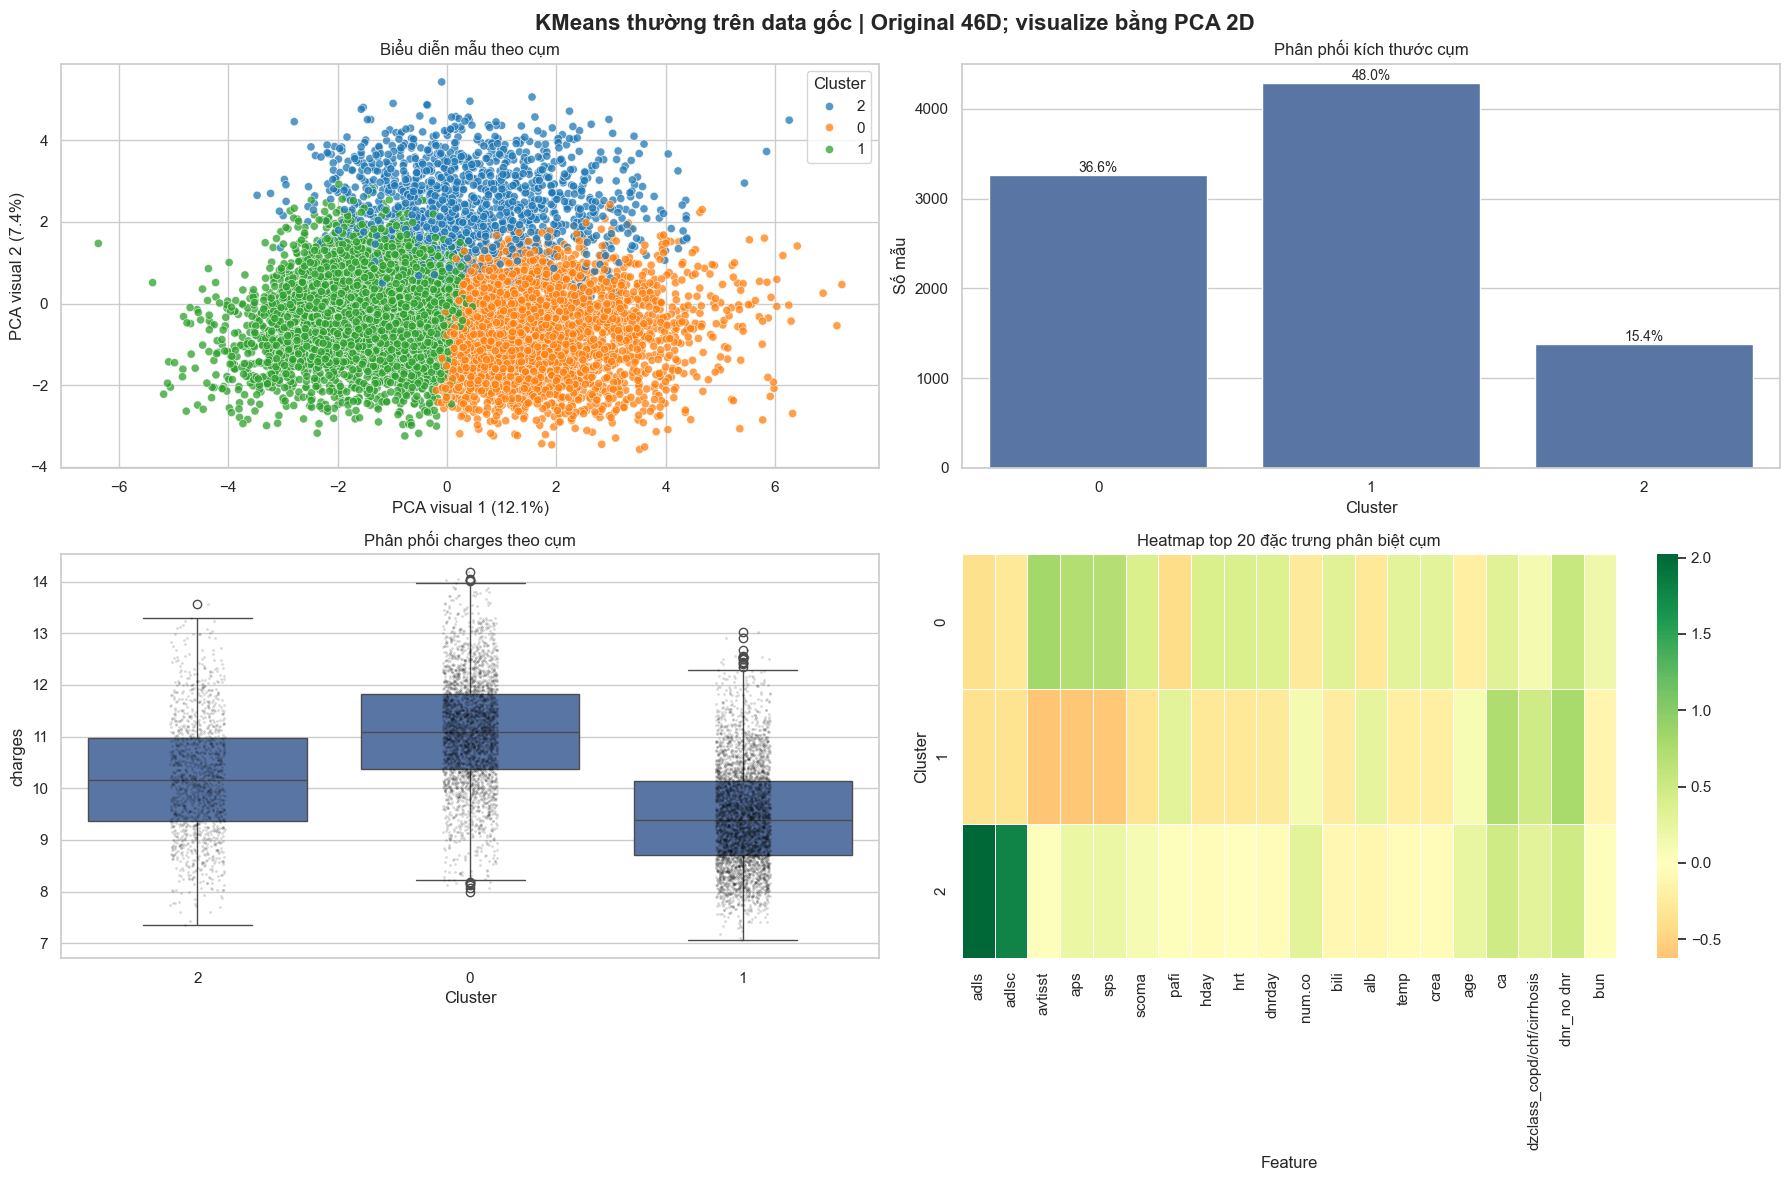


=== Phân phối kích thước cụm ===


,cluster,n_samples,ratio
0,0,3266,0.365611
1,1,4292,0.480466
2,2,1375,0.153924



=== Thống kê charges theo cụm ===


,cluster,n,mean,median,std,min,max
0,0,3266,11.095624,11.095127,1.055711,7.988543,14.176971
1,1,4292,9.463251,9.391787,0.983919,7.064759,13.034190
2,2,1375,10.203903,10.156151,1.126609,7.348588,13.573091



=== Tỷ lệ nhóm charges Low/Medium/High trong từng cụm ===


charges,Low,Medium,High
cluster,,,
0,0.069198,0.295468,0.635334
1,0.547763,0.341100,0.111137
2,0.291636,0.398545,0.309818



=== Top đặc trưng phân biệt cụm mạnh nhất ===
['adls', 'adlsc', 'avtisst', 'aps', 'sps', 'scoma', 'pafi', 'hday', 'hrt', 'dnrday', 'num.co', 'bili', 'alb', 'temp', 'crea', 'age', 'ca', 'dzclass_copd/chf/cirrhosis', 'dnr_no dnr', 'bun']
RUNNING: KMeans thường sau PCA | PCA continuous + discrete

=== Metrics ===


,model,k,silhouette,davies_bouldin,calinski_harabasz,ari_vs_charges_bins,fmi_vs_charges_bins,eta2_charges_by_cluster,min_cluster_size,max_cluster_size,min_cluster_ratio,max_cluster_ratio,reduction,algorithm
0,KMeans thường sau PCA,3,0.133017,2.241736,1087.529123,0.186449,0.478751,0.340167,1425,4299,0.159521,0.481249,PCA continuous + discrete,kmeans


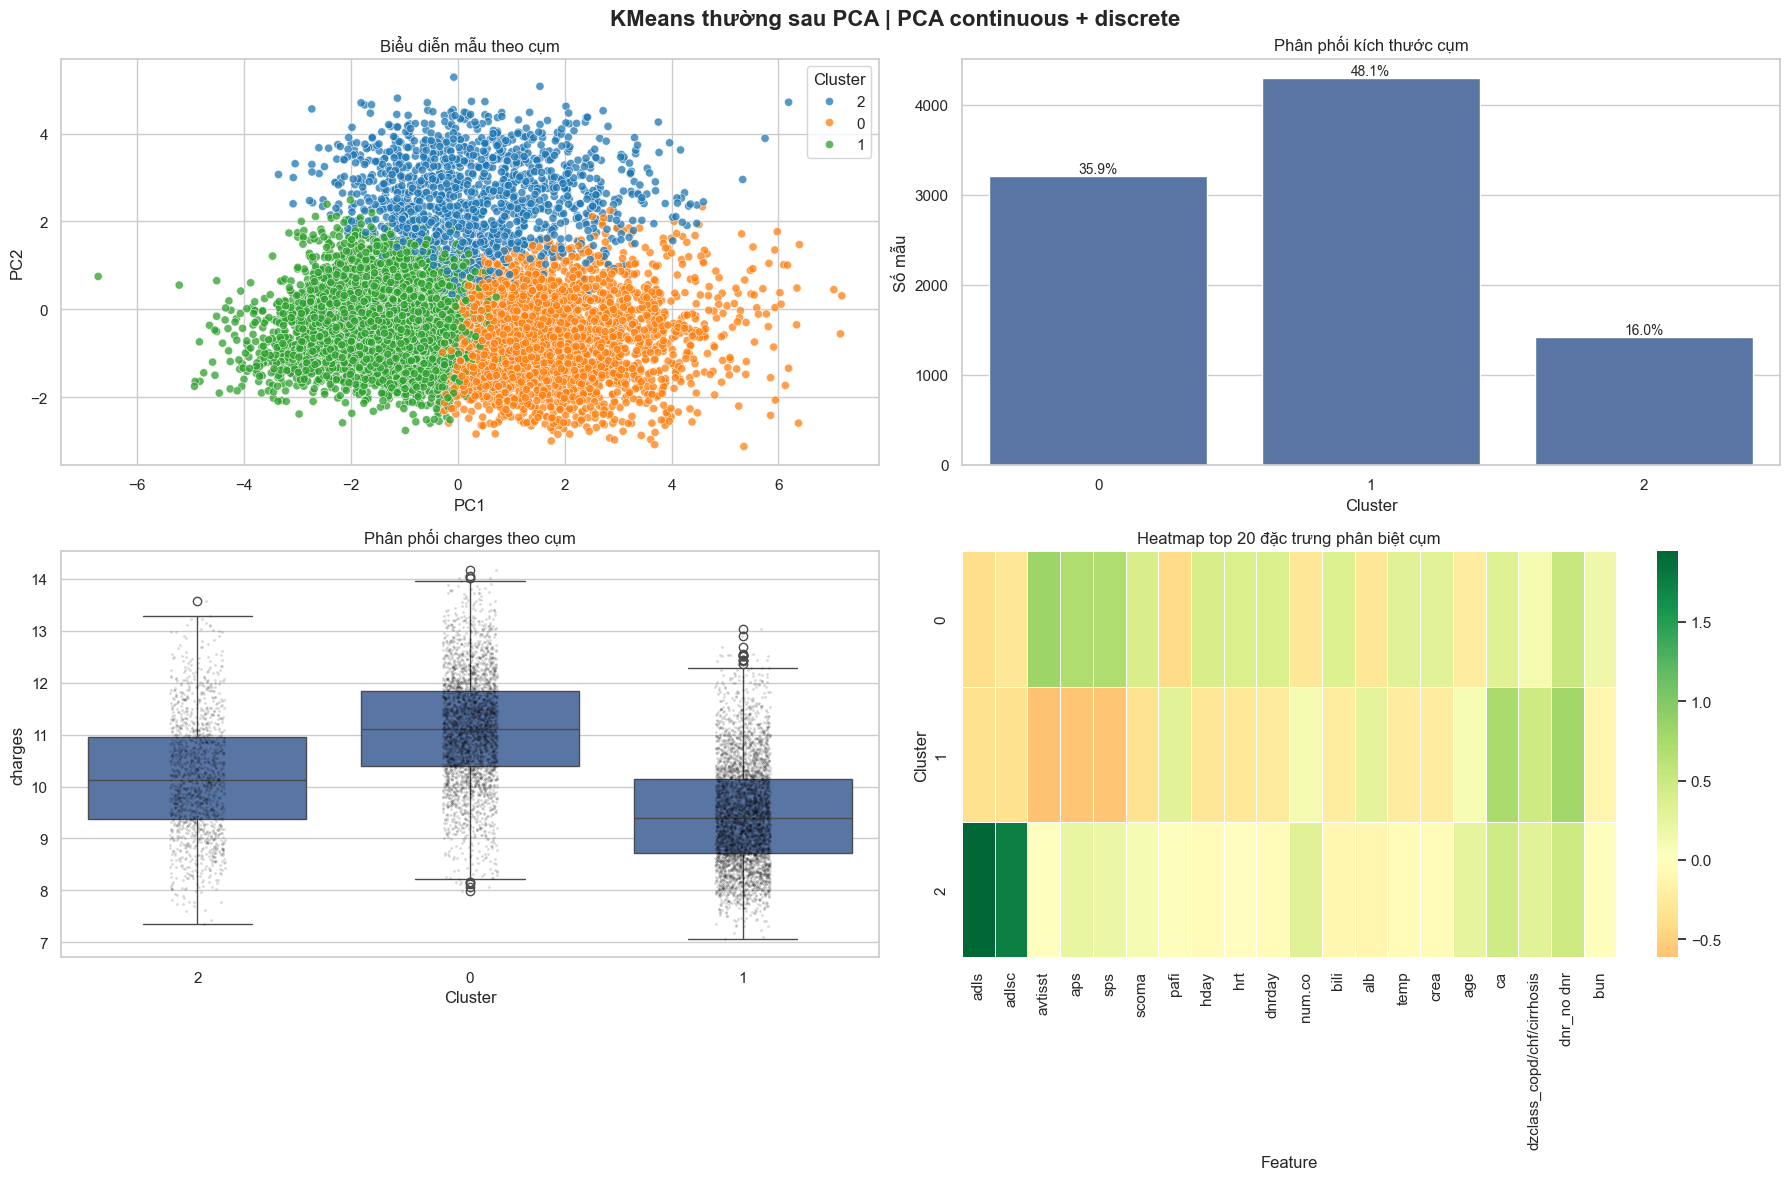


=== Phân phối kích thước cụm ===


,cluster,n_samples,ratio
0,0,3209,0.359230
1,1,4299,0.481249
2,2,1425,0.159521



=== Thống kê charges theo cụm ===


,cluster,n,mean,median,std,min,max
0,0,3209,11.108956,11.109473,1.055280,7.988543,14.176971
1,1,4299,9.471697,9.399720,0.988564,7.064759,13.034190
2,2,1425,10.187707,10.134454,1.118647,7.348588,13.573091



=== Tỷ lệ nhóm charges Low/Medium/High trong từng cụm ===


charges,Low,Medium,High
cluster,,,
0,0.067622,0.292303,0.640075
1,0.544313,0.341707,0.113980
2,0.295439,0.400000,0.304561



=== Top đặc trưng phân biệt cụm mạnh nhất ===
['adls', 'adlsc', 'avtisst', 'aps', 'sps', 'scoma', 'pafi', 'hday', 'hrt', 'dnrday', 'num.co', 'bili', 'alb', 'temp', 'crea', 'age', 'ca', 'dzclass_copd/chf/cirrhosis', 'dnr_no dnr', 'bun']
RUNNING: K-Medoids + Gower sau PCA | PCA continuous + discrete
Đang tính Gower distance matrix. Cell này có thể chạy lâu nếu n_samples lớn.

=== Metrics ===


,model,k,silhouette,davies_bouldin,calinski_harabasz,ari_vs_charges_bins,fmi_vs_charges_bins,eta2_charges_by_cluster,min_cluster_size,max_cluster_size,min_cluster_ratio,max_cluster_ratio,reduction,algorithm
0,K-Medoids + Gower sau PCA,3,0.122023,4.534891,309.8813,0.044886,0.425417,0.117331,1146,5660,0.128288,0.633606,PCA continuous + discrete,gower_kmedoids


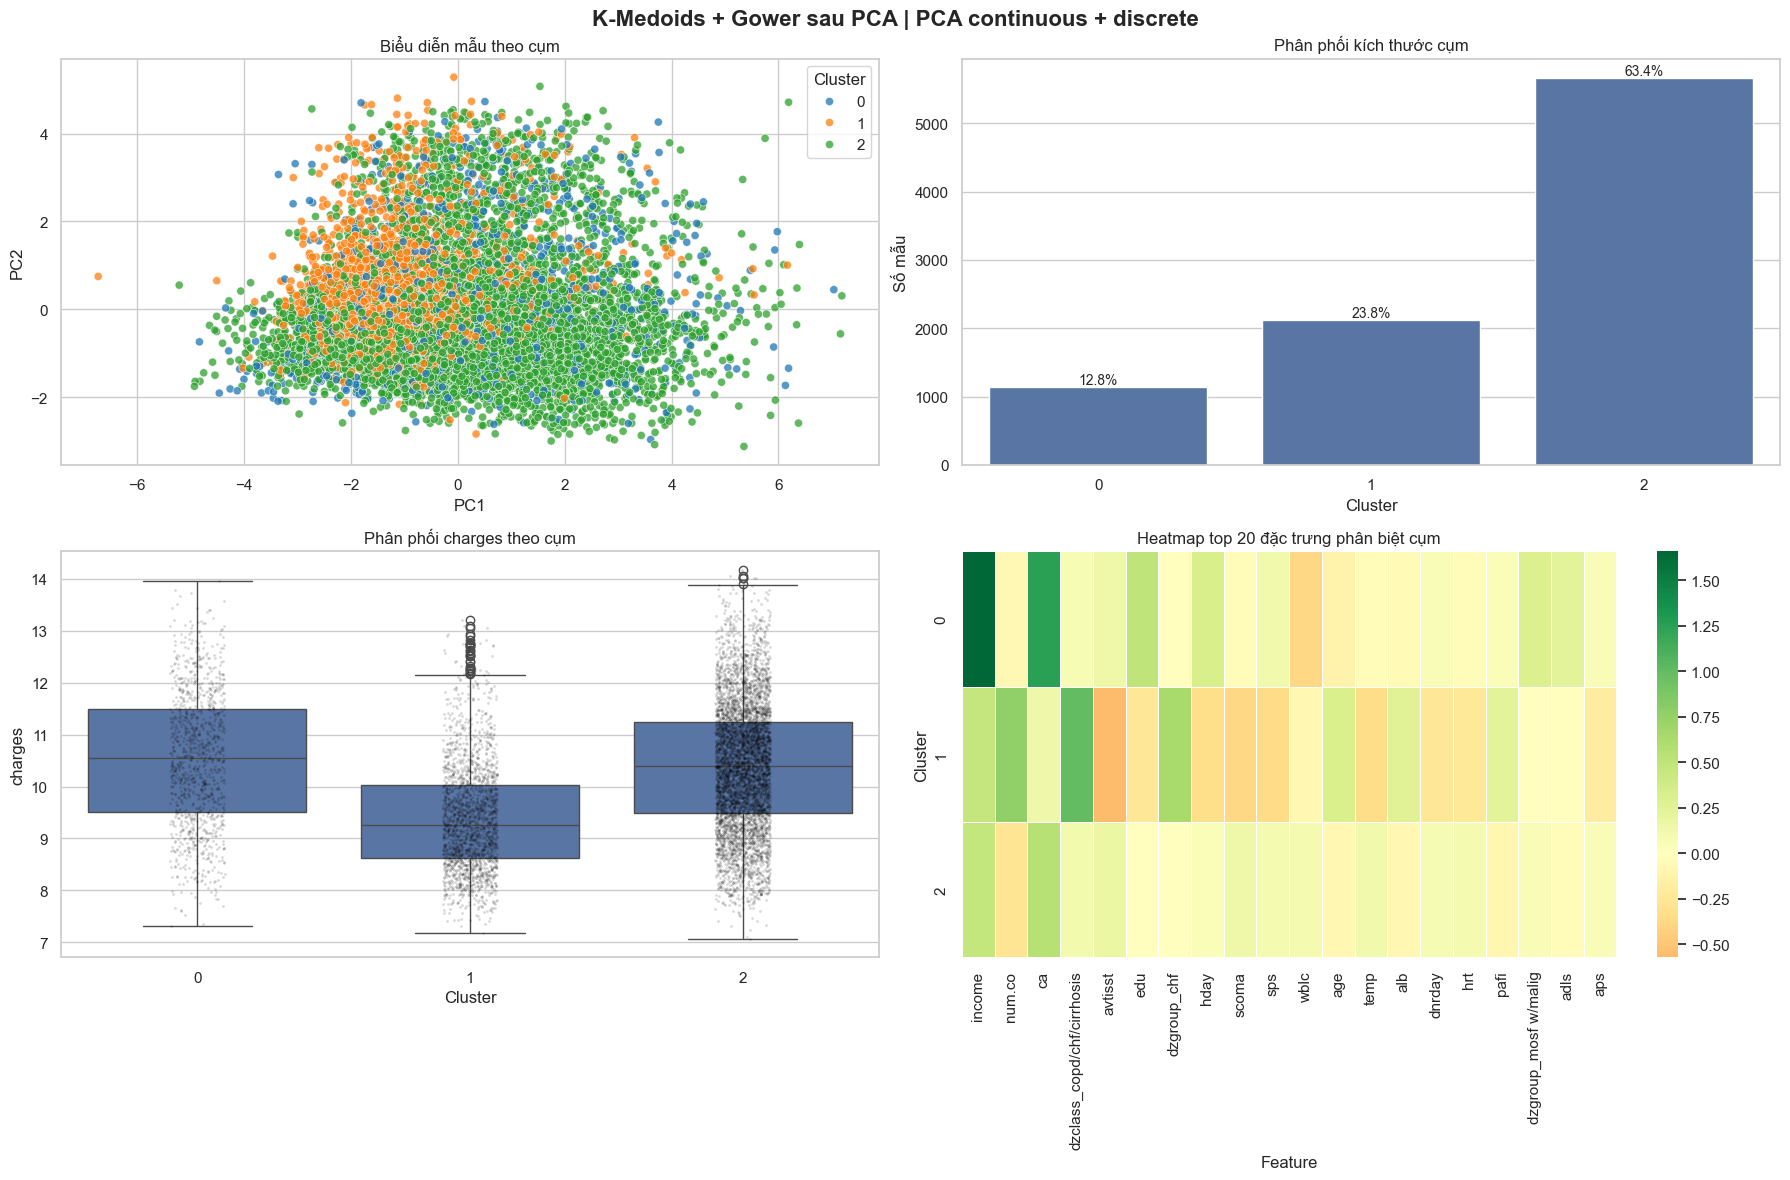


=== Phân phối kích thước cụm ===


,cluster,n_samples,ratio
0,0,1146,0.128288
1,1,2127,0.238106
2,2,5660,0.633606



=== Thống kê charges theo cụm ===


,cluster,n,mean,median,std,min,max
0,0,1146,10.534141,10.554893,1.288188,7.319865,13.965227
1,1,2127,9.398337,9.263502,1.028637,7.181933,13.215385
2,2,5660,10.392678,10.385234,1.235048,7.064759,14.176971



=== Tỷ lệ nhóm charges Low/Medium/High trong từng cụm ===


charges,Low,Medium,High
cluster,,,
0,0.250436,0.304538,0.445026
1,0.585331,0.310296,0.104372
2,0.255477,0.347703,0.396820



=== Top đặc trưng phân biệt cụm mạnh nhất ===
['income', 'num.co', 'ca', 'dzclass_copd/chf/cirrhosis', 'avtisst', 'edu', 'dzgroup_chf', 'hday', 'scoma', 'sps', 'wblc', 'age', 'temp', 'alb', 'dnrday', 'hrt', 'pafi', 'dzgroup_mosf w/malig', 'adls', 'aps']
RUNNING: KMeans Constrained sau PCA | PCA continuous + discrete

=== Metrics ===


,model,k,silhouette,davies_bouldin,calinski_harabasz,ari_vs_charges_bins,fmi_vs_charges_bins,eta2_charges_by_cluster,min_cluster_size,max_cluster_size,min_cluster_ratio,max_cluster_ratio,reduction,algorithm
0,KMeans Constrained sau PCA,3,0.111307,2.480577,1042.055612,0.176029,0.454284,0.34836,2381,3573,0.26654,0.399978,PCA continuous + discrete,constrained


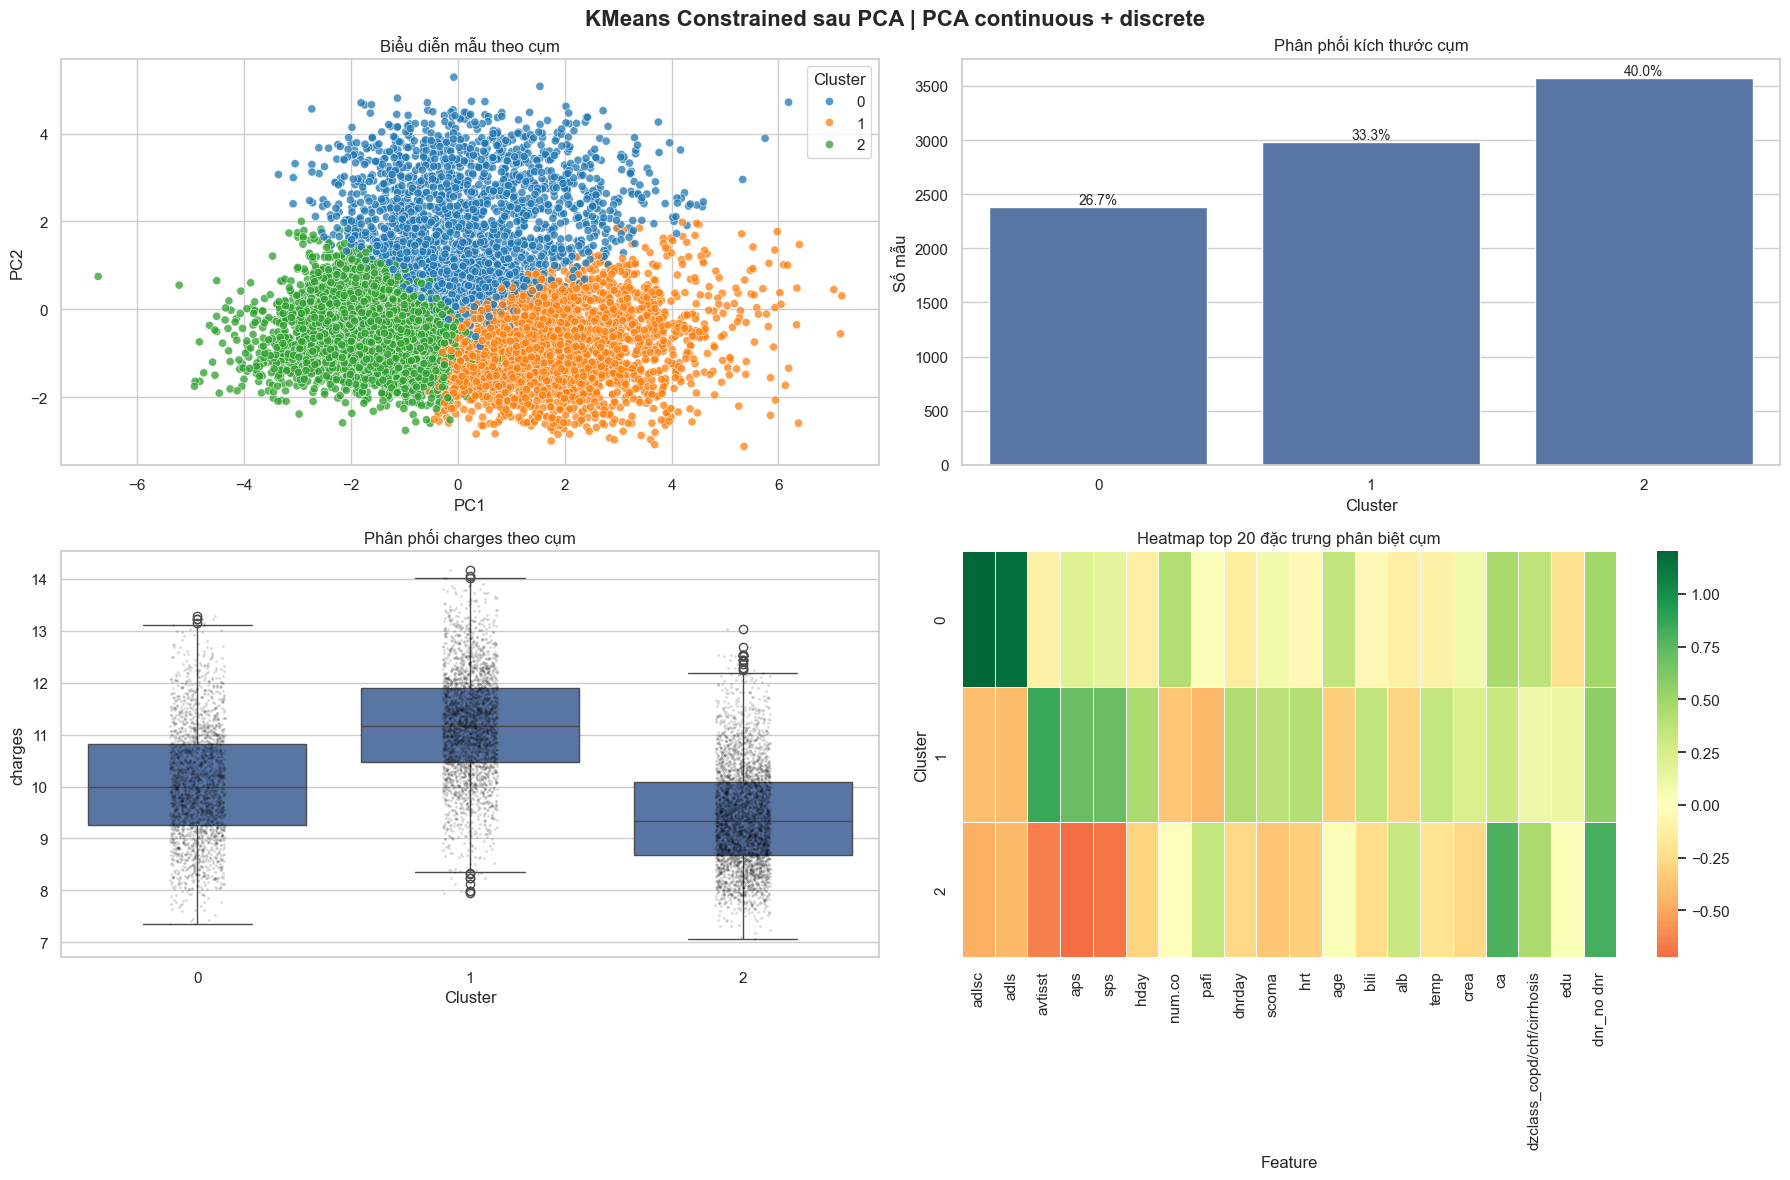


=== Phân phối kích thước cụm ===


,cluster,n_samples,ratio
0,0,2381,0.266540
1,1,2979,0.333483
2,2,3573,0.399978



=== Thống kê charges theo cụm ===


,cluster,n,mean,median,std,min,max
0,0,2381,10.056813,9.999843,1.086446,7.348588,13.293285
1,1,2979,11.173366,11.167388,1.034656,7.957982,14.176971
2,2,3573,9.419037,9.326433,0.981178,7.064759,13.034190



=== Tỷ lệ nhóm charges Low/Medium/High trong từng cụm ===


charges,Low,Medium,High
cluster,,,
0,0.327173,0.409912,0.262915
1,0.054381,0.280295,0.665324
2,0.570109,0.326336,0.103554



=== Top đặc trưng phân biệt cụm mạnh nhất ===
['adlsc', 'adls', 'avtisst', 'aps', 'sps', 'hday', 'num.co', 'pafi', 'dnrday', 'scoma', 'hrt', 'age', 'bili', 'alb', 'temp', 'crea', 'ca', 'dzclass_copd/chf/cirrhosis', 'edu', 'dnr_no dnr']
RUNNING: KMeans thường sau UMAP | UMAP

=== Metrics ===


,model,k,silhouette,davies_bouldin,calinski_harabasz,ari_vs_charges_bins,fmi_vs_charges_bins,eta2_charges_by_cluster,min_cluster_size,max_cluster_size,min_cluster_ratio,max_cluster_ratio,reduction,algorithm
0,KMeans thường sau UMAP,3,0.373489,1.07436,10245.05957,0.158473,0.459424,0.322237,1374,3998,0.153812,0.447554,UMAP,kmeans


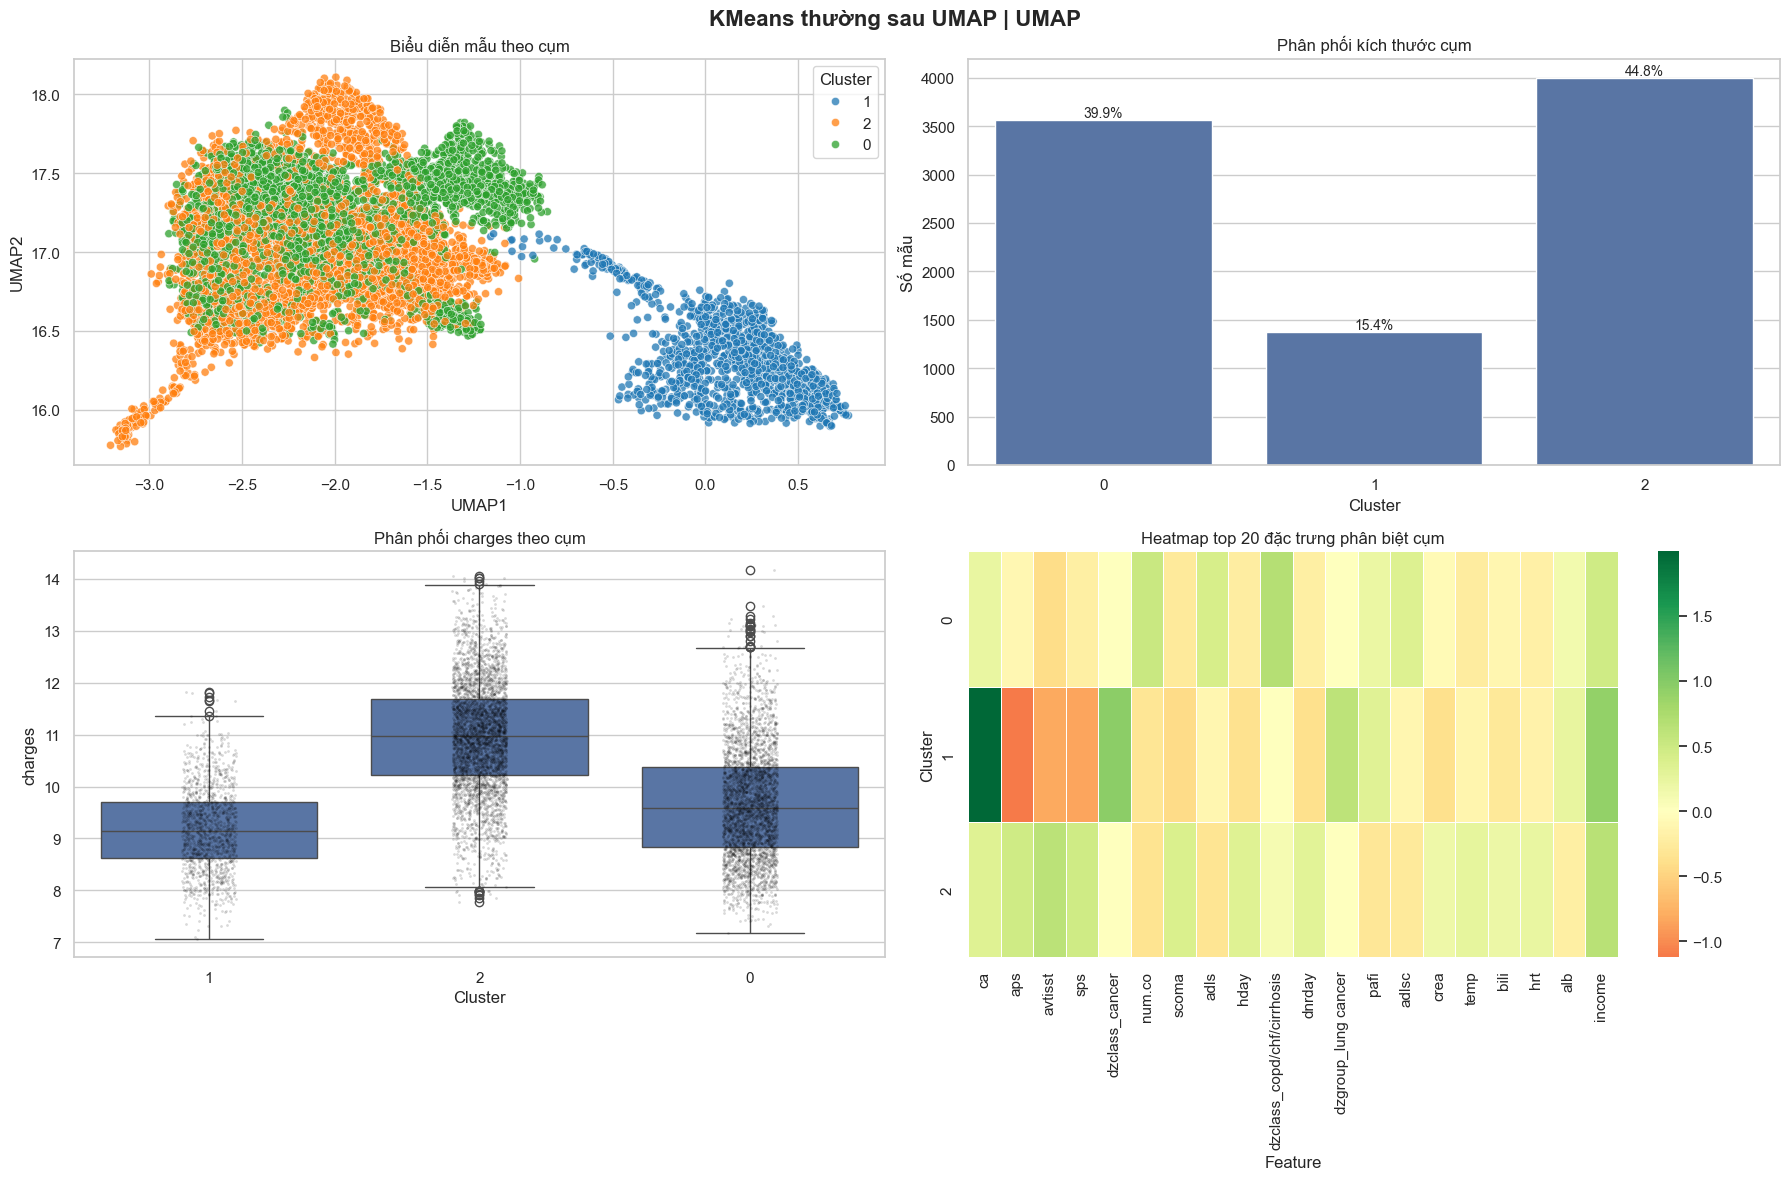


=== Phân phối kích thước cụm ===


,cluster,n_samples,ratio
0,0,3561,0.398634
1,1,1374,0.153812
2,2,3998,0.447554



=== Thống kê charges theo cụm ===


,cluster,n,mean,median,std,min,max
0,0,3561,9.676422,9.587680,1.081618,7.181933,14.176971
1,1,1374,9.187473,9.147666,0.811029,7.064759,11.829341
2,2,3998,10.956384,10.964748,1.089719,7.765993,14.057160



=== Tỷ lệ nhóm charges Low/Medium/High trong từng cụm ===


charges,Low,Medium,High
cluster,,,
0,0.470373,0.363381,0.166245
1,0.671033,0.296215,0.032751
2,0.095298,0.319160,0.585543



=== Top đặc trưng phân biệt cụm mạnh nhất ===
['ca', 'aps', 'avtisst', 'sps', 'dzclass_cancer', 'num.co', 'scoma', 'adls', 'hday', 'dzclass_copd/chf/cirrhosis', 'dnrday', 'dzgroup_lung cancer', 'pafi', 'adlsc', 'crea', 'temp', 'bili', 'hrt', 'alb', 'income']
RUNNING: K-Medoids + Gower sau UMAP | UMAP
Đang tính Gower distance matrix. Cell này có thể chạy lâu nếu n_samples lớn.

=== Metrics ===


,model,k,silhouette,davies_bouldin,calinski_harabasz,ari_vs_charges_bins,fmi_vs_charges_bins,eta2_charges_by_cluster,min_cluster_size,max_cluster_size,min_cluster_ratio,max_cluster_ratio,reduction,algorithm
0,K-Medoids + Gower sau UMAP,3,0.387756,1.153752,9486.216797,0.135789,0.445257,0.302909,1370,4070,0.153364,0.455614,UMAP,gower_kmedoids


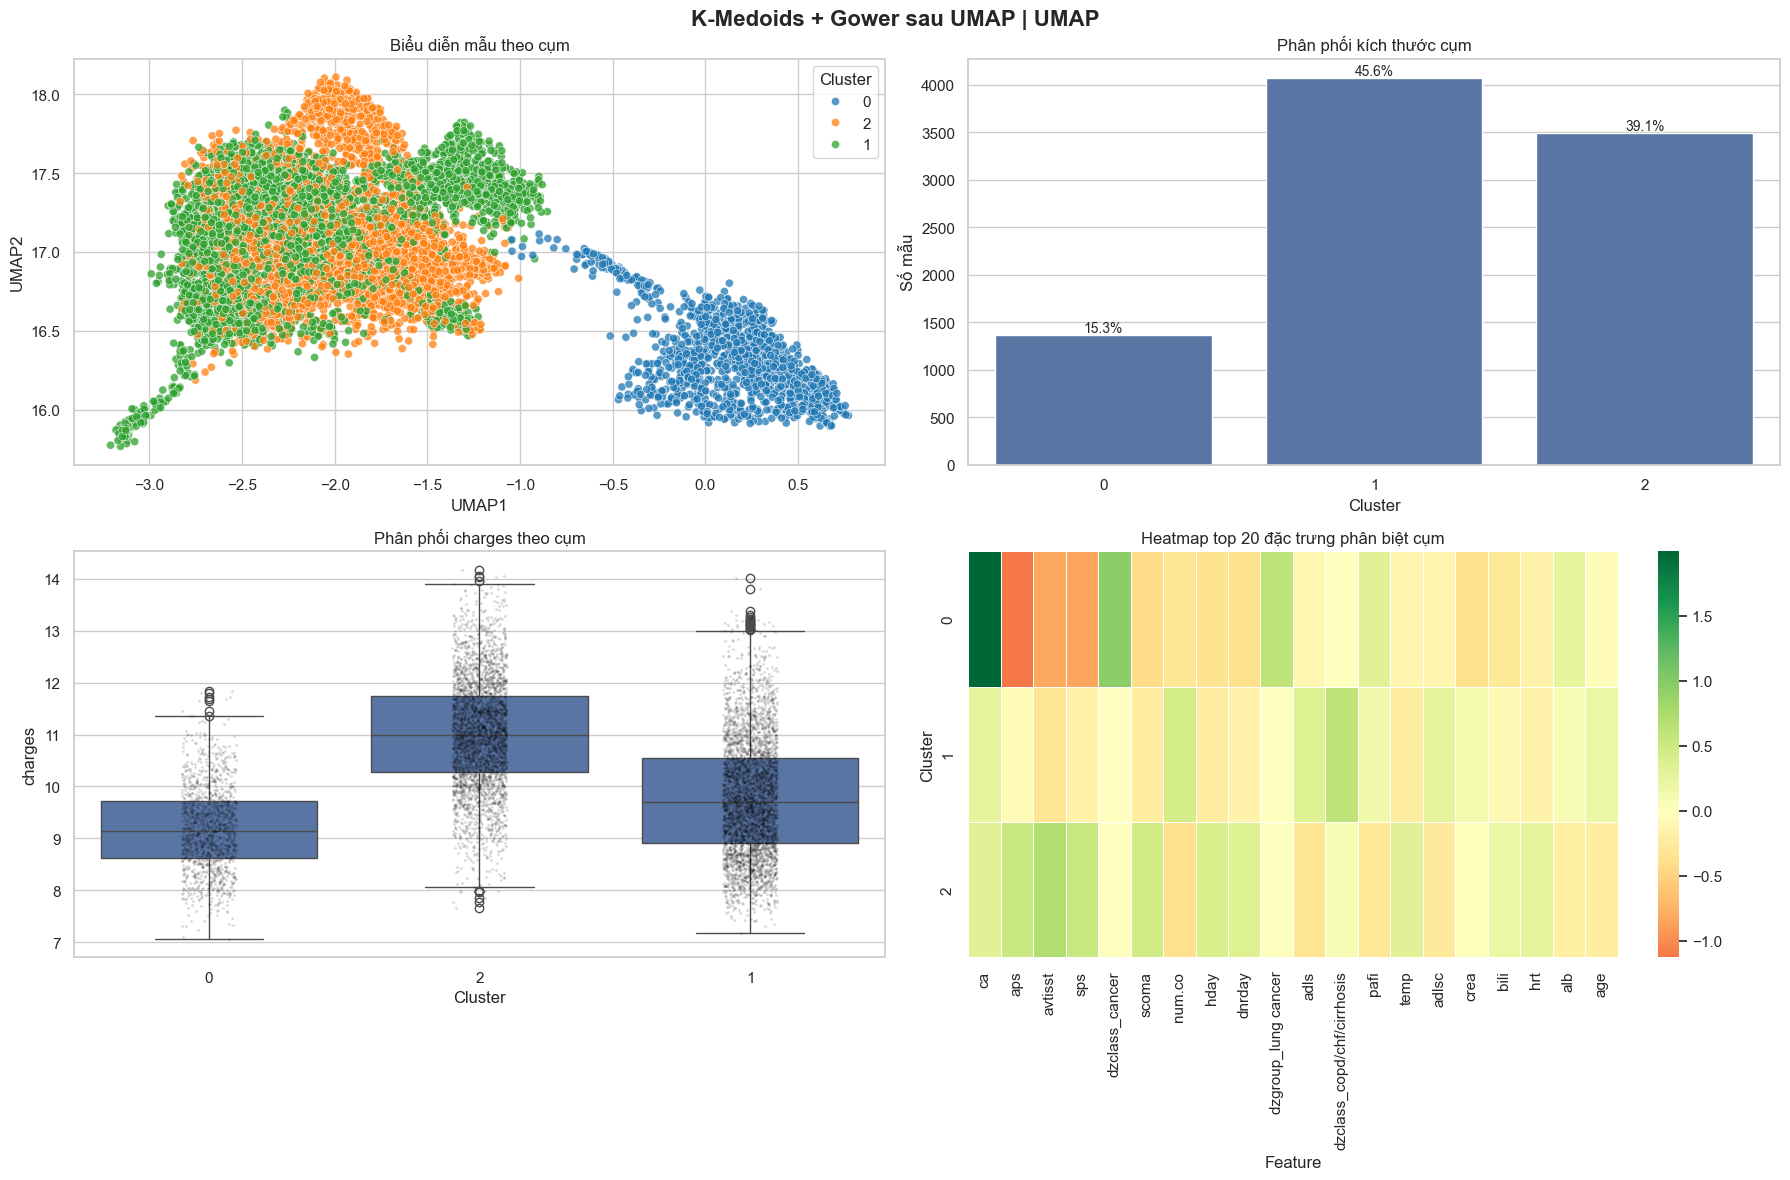


=== Phân phối kích thước cụm ===


,cluster,n_samples,ratio
0,0,1370,0.153364
1,1,4070,0.455614
2,2,3493,0.391022



=== Thống kê charges theo cụm ===


,cluster,n,mean,median,std,min,max
0,0,1370,9.189102,9.149741,0.811259,7.064759,11.829341
1,1,4070,9.787160,9.691933,1.130793,7.181933,14.019893
2,2,3493,11.011203,10.998242,1.068959,7.662938,14.176971



=== Tỷ lệ nhóm charges Low/Medium/High trong từng cụm ===


charges,Low,Medium,High
cluster,,,
0,0.670073,0.297080,0.032847
1,0.438084,0.356265,0.205651
2,0.079301,0.320641,0.600057



=== Top đặc trưng phân biệt cụm mạnh nhất ===
['ca', 'aps', 'avtisst', 'sps', 'dzclass_cancer', 'scoma', 'num.co', 'hday', 'dnrday', 'dzgroup_lung cancer', 'adls', 'dzclass_copd/chf/cirrhosis', 'pafi', 'temp', 'adlsc', 'crea', 'bili', 'hrt', 'alb', 'age']
RUNNING: KMeans Constrained sau UMAP | UMAP

=== Metrics ===


,model,k,silhouette,davies_bouldin,calinski_harabasz,ari_vs_charges_bins,fmi_vs_charges_bins,eta2_charges_by_cluster,min_cluster_size,max_cluster_size,min_cluster_ratio,max_cluster_ratio,reduction,algorithm
0,KMeans Constrained sau UMAP,3,0.321999,1.0962,7065.390625,0.163919,0.446262,0.319224,2381,3573,0.26654,0.399978,UMAP,constrained


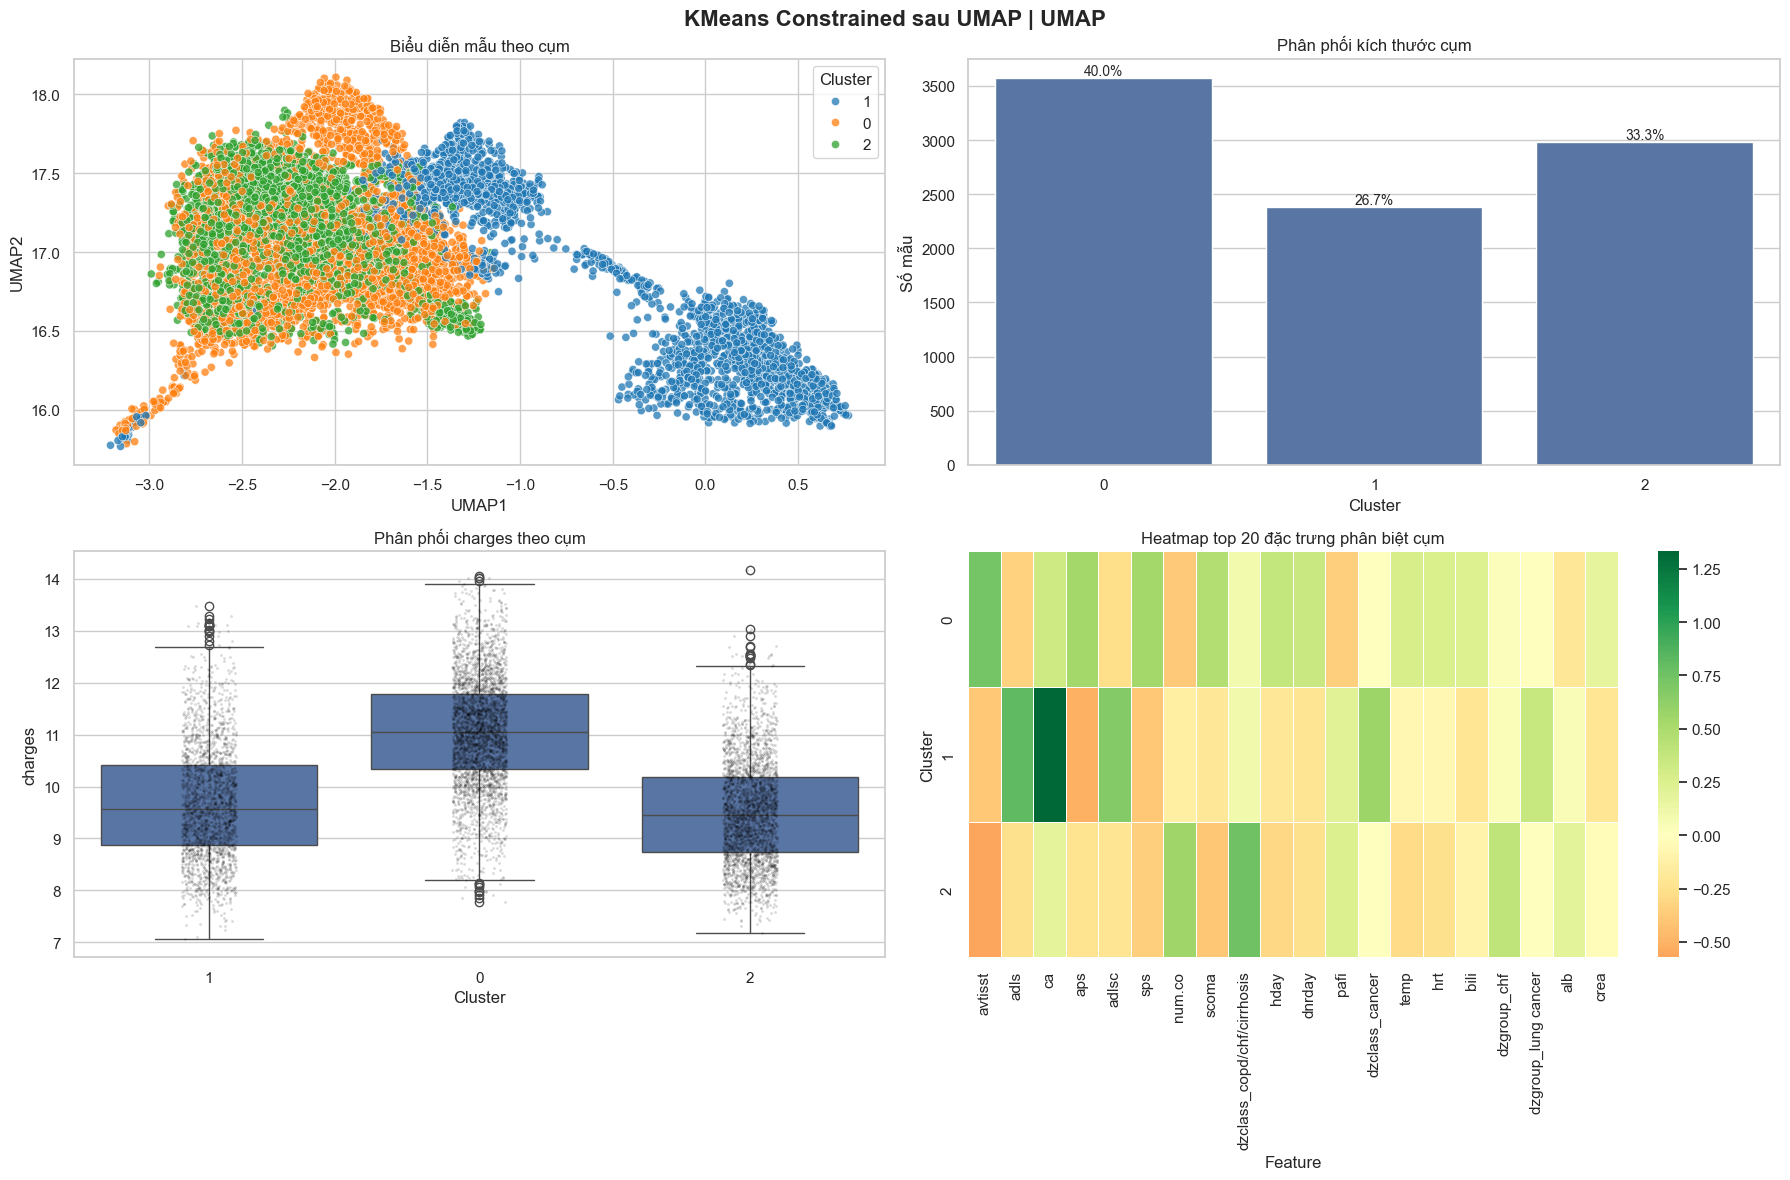


=== Phân phối kích thước cụm ===


,cluster,n_samples,ratio
0,0,3573,0.399978
1,1,2381,0.266540
2,2,2979,0.333483



=== Thống kê charges theo cụm ===


,cluster,n,mean,median,std,min,max
0,0,3573,11.050671,11.053426,1.068286,7.765993,14.057160
1,1,2381,9.694094,9.574011,1.102220,7.064759,13.476612
2,2,2979,9.506298,9.450774,0.985119,7.181933,14.176971



=== Tỷ lệ nhóm charges Low/Medium/High trong từng cụm ===


charges,Low,Medium,High
cluster,,,
0,0.077526,0.300868,0.621606
1,0.479630,0.344393,0.175976
2,0.523330,0.363209,0.113461



=== Top đặc trưng phân biệt cụm mạnh nhất ===
['avtisst', 'adls', 'ca', 'aps', 'adlsc', 'sps', 'num.co', 'scoma', 'dzclass_copd/chf/cirrhosis', 'hday', 'dnrday', 'pafi', 'dzclass_cancer', 'temp', 'hrt', 'bili', 'dzgroup_chf', 'dzgroup_lung cancer', 'alb', 'crea']

Tổng số phương pháp đã chạy: 7


In [9]:
def fit_kmeans(X_train, k=K_FINAL, name="KMeans"):
    model = KMeans(n_clusters=k, n_init=20, random_state=RANDOM_STATE)
    labels = model.fit_predict(X_train)
    return labels, model


def fit_kmeans_constrained(X_train, k=K_FINAL, name="KMeans Constrained", tolerance=0.20):
    if not HAS_KMEANS_CONSTRAINED:
        print(f"Bỏ qua {name}: chưa cài k_means_constrained.")
        return None, None

    n = len(X_train)
    base = n // k
    size_min = max(1, int(base * (1 - tolerance)))
    size_max = int(math.ceil(base * (1 + tolerance)))

    model = KMeansConstrained(
        n_clusters=k,
        size_min=size_min,
        size_max=size_max,
        random_state=RANDOM_STATE,
    )
    labels = model.fit_predict(np.asarray(X_train))
    return labels, model


def run_one_method(
    X_cluster,
    X_metric,
    X_original,
    y,
    method_name,
    reduction_name,
    algorithm="kmeans",
    categorical_cols_for_gower=None,
):
    print("=" * 90)
    print(f"RUNNING: {method_name} | {reduction_name}")
    print("=" * 90)

    distance_matrix = None
    model = None

    if algorithm == "kmeans":
        labels, model = fit_kmeans(X_cluster, K_FINAL, method_name)

    elif algorithm == "constrained":
        labels, model = fit_kmeans_constrained(X_cluster, K_FINAL, method_name)
        if labels is None:
            return None

    elif algorithm == "gower_kmedoids":
        print("Đang tính Gower distance matrix. Cell này có thể chạy lâu nếu n_samples lớn.")
        distance_matrix = gower_distance_matrix(X_cluster, categorical_cols=categorical_cols_for_gower)
        labels, medoids = kmedoids_precomputed(distance_matrix, K_FINAL, random_state=RANDOM_STATE)
        model = {"medoids": medoids}

    else:
        raise ValueError(f"Unknown algorithm: {algorithm}")

    metrics = evaluate_clustering(
        X_metric=X_metric,
        labels=labels,
        y=y,
        model_name=method_name,
        distance_matrix=distance_matrix,
    )
    metrics["reduction"] = reduction_name
    metrics["algorithm"] = algorithm

    print("\n=== Metrics ===")
    display(pd.DataFrame([metrics]))

    relation = plot_cluster_dashboard(
        X_used=X_cluster,
        X_original=X_original,
        y=y,
        labels=labels,
        model_name=method_name,
        reduction_name=reduction_name,
    )

    return {
        "name": method_name,
        "reduction": reduction_name,
        "algorithm": algorithm,
        "labels": labels,
        "model": model,
        "metrics": metrics,
        "relation": relation,
        "distance_matrix": distance_matrix,
    }

all_results = []

# 1. Baseline: data gốc 46D, KMeans thường
res = run_one_method(
    X_cluster=X,
    X_metric=X,
    X_original=X,
    y=y,
    method_name="KMeans thường trên data gốc",
    reduction_name="Original 46D; visualize bằng PCA 2D",
    algorithm="kmeans",
)
all_results.append(res)

# 2. PCA + KMeans
res = run_one_method(
    X_cluster=X_pca_reduced,
    X_metric=X_pca_reduced,
    X_original=X,
    y=y,
    method_name="KMeans thường sau PCA",
    reduction_name="PCA continuous + discrete",
    algorithm="kmeans",
)
all_results.append(res)

# 3. PCA + Gower K-Medoids
pca_gower_cat_cols = [c for c in discrete_cols if c in X_pca_reduced.columns]
res = run_one_method(
    X_cluster=X_pca_reduced,
    X_metric=X_pca_reduced,
    X_original=X,
    y=y,
    method_name="K-Medoids + Gower sau PCA",
    reduction_name="PCA continuous + discrete",
    algorithm="gower_kmedoids",
    categorical_cols_for_gower=pca_gower_cat_cols,
)
all_results.append(res)

# 4. PCA + KMeans Constrained
res = run_one_method(
    X_cluster=X_pca_reduced,
    X_metric=X_pca_reduced,
    X_original=X,
    y=y,
    method_name="KMeans Constrained sau PCA",
    reduction_name="PCA continuous + discrete",
    algorithm="constrained",
)
if res is not None:
    all_results.append(res)

# 5-7. UMAP methods
if HAS_UMAP and X_umap_reduced is not None:
    res = run_one_method(
        X_cluster=X_umap_reduced,
        X_metric=X_umap_reduced,
        X_original=X,
        y=y,
        method_name="KMeans thường sau UMAP",
        reduction_name="UMAP",
        algorithm="kmeans",
    )
    all_results.append(res)

    # Sau UMAP toàn bộ feature đều là embedding liên tục, không còn cột categorical gốc.
    # Vì vậy Gower ở đây gần tương đương numeric distance trên embedding UMAP.
    res = run_one_method(
        X_cluster=X_umap_reduced,
        X_metric=X_umap_reduced,
        X_original=X,
        y=y,
        method_name="K-Medoids + Gower sau UMAP",
        reduction_name="UMAP",
        algorithm="gower_kmedoids",
        categorical_cols_for_gower=[],
    )
    all_results.append(res)

    res = run_one_method(
        X_cluster=X_umap_reduced,
        X_metric=X_umap_reduced,
        X_original=X,
        y=y,
        method_name="KMeans Constrained sau UMAP",
        reduction_name="UMAP",
        algorithm="constrained",
    )
    if res is not None:
        all_results.append(res)
else:
    print("Bỏ qua nhóm UMAP vì UMAP chưa khả dụng.")

# Loại bỏ None nếu có
all_results = [r for r in all_results if r is not None]
print(f"\nTổng số phương pháp đã chạy: {len(all_results)}")

## 10. Bảng so sánh tổng hợp các phương pháp

,model,k,silhouette,davies_bouldin,calinski_harabasz,ari_vs_charges_bins,fmi_vs_charges_bins,eta2_charges_by_cluster,min_cluster_size,max_cluster_size,min_cluster_ratio,max_cluster_ratio,reduction,algorithm
0,K-Medoids + Gower sau UMAP,3,0.387756,1.153752,9486.216797,0.135789,0.445257,0.302909,1370,4070,0.153364,0.455614,UMAP,gower_kmedoids
1,KMeans thường sau UMAP,3,0.373489,1.074360,10245.059570,0.158473,0.459424,0.322237,1374,3998,0.153812,0.447554,UMAP,kmeans
2,KMeans Constrained sau UMAP,3,0.321999,1.096200,7065.390625,0.163919,0.446262,0.319224,2381,3573,0.266540,0.399978,UMAP,constrained
3,KMeans thường sau PCA,3,0.133017,2.241736,1087.529123,0.186449,0.478751,0.340167,1425,4299,0.159521,0.481249,PCA continuous + discrete,kmeans
4,K-Medoids + Gower sau PCA,3,0.122023,4.534891,309.881300,0.044886,0.425417,0.117331,1146,5660,0.128288,0.633606,PCA continuous + discrete,gower_kmedoids
5,KMeans Constrained sau PCA,3,0.111307,2.480577,1042.055612,0.176029,0.454284,0.348360,2381,3573,0.266540,0.399978,PCA continuous + discrete,constrained
6,KMeans thường trên data gốc,3,0.087254,2.988404,622.186976,0.189535,0.481574,0.341391,1375,4292,0.153924,0.480466,Original 46D; visualize bằng PCA 2D,kmeans


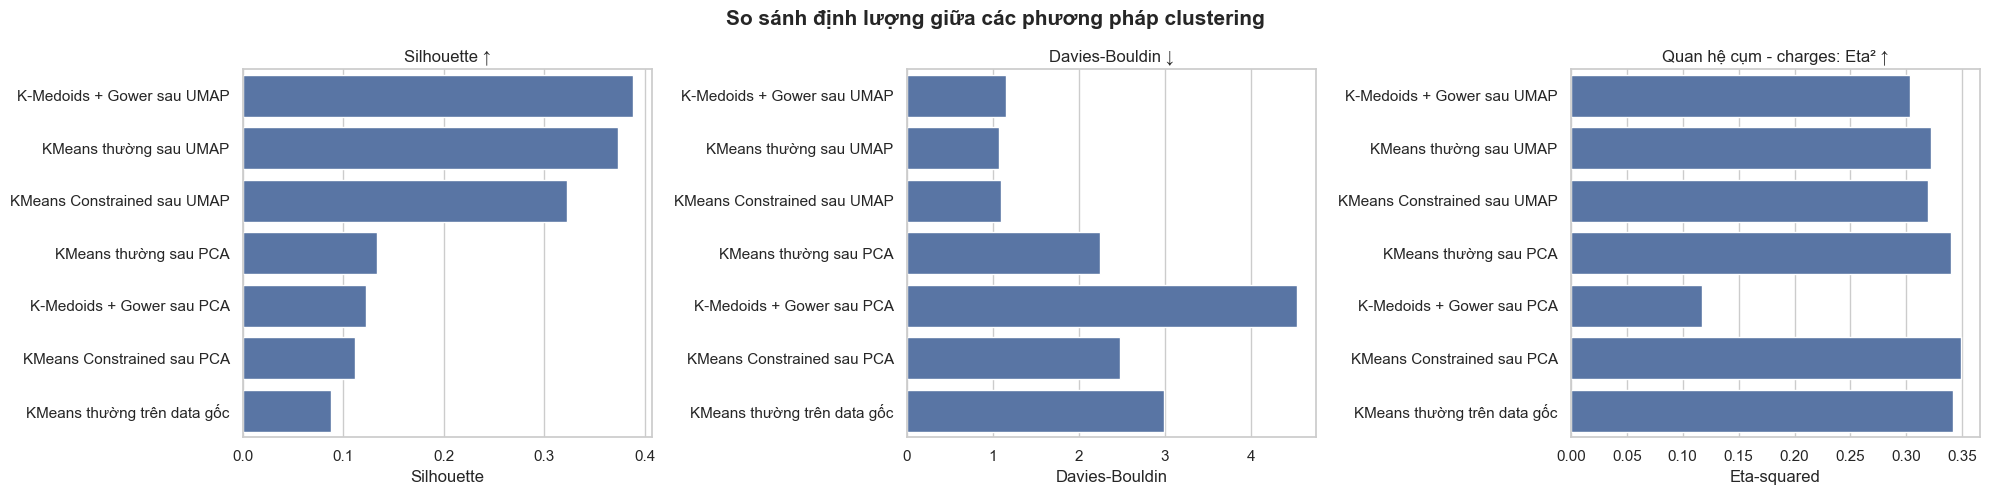

In [10]:
metrics_df = pd.DataFrame([r["metrics"] for r in all_results])

# Sắp xếp theo silhouette giảm dần, Davies-Bouldin tăng dần
metrics_df = metrics_df.sort_values(
    by=["silhouette", "davies_bouldin"],
    ascending=[False, True]
).reset_index(drop=True)

display(metrics_df)

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle("So sánh định lượng giữa các phương pháp clustering", fontsize=15, fontweight="bold")

sns.barplot(data=metrics_df, y="model", x="silhouette", ax=axes[0])
axes[0].set_title("Silhouette ↑")
axes[0].set_xlabel("Silhouette")
axes[0].set_ylabel("")

sns.barplot(data=metrics_df, y="model", x="davies_bouldin", ax=axes[1])
axes[1].set_title("Davies-Bouldin ↓")
axes[1].set_xlabel("Davies-Bouldin")
axes[1].set_ylabel("")

sns.barplot(data=metrics_df, y="model", x="eta2_charges_by_cluster", ax=axes[2])
axes[2].set_title("Quan hệ cụm - charges: Eta² ↑")
axes[2].set_xlabel("Eta-squared")
axes[2].set_ylabel("")

plt.tight_layout()
plt.show()

In [11]:
best_sil = metrics_df.iloc[0]
best_charge = metrics_df.sort_values("eta2_charges_by_cluster", ascending=False).iloc[0]

print("=== GỢI Ý NHẬN XÉT ===")
print(f"1. Theo Silhouette, phương pháp tốt nhất là: {best_sil['model']} ({best_sil['reduction']}) với Silhouette = {best_sil['silhouette']:.4f}.")
print(f"2. Theo Davies-Bouldin, giá trị càng thấp càng tốt. Cần ưu tiên phương pháp có DB nhỏ nhưng cụm không quá lệch kích thước.")
print(f"3. Theo Calinski-Harabasz, giá trị càng cao càng tốt, phản ánh độ tách cụm so với độ chặt trong cụm.")
print(f"4. Quan hệ giữa cụm và charges mạnh nhất theo eta-squared thuộc về: {best_charge['model']} với Eta² = {best_charge['eta2_charges_by_cluster']:.4f}.")
print("5. Nếu một phương pháp có Silhouette cao nhưng phân bố kích thước cụm quá lệch, cần cân nhắc KMeans Constrained để tạo cụm cân bằng hơn.")
print("6. Nếu muốn giải thích cụm theo bệnh/lâm sàng/chi phí, nên ưu tiên bảng charges theo cụm, crosstab Low-Medium-High và heatmap top feature.")
print("7. Không nên nói 'KMeans dùng Gower distance'. Nên viết chính xác là 'K-Medoids với Gower distance' vì KMeans chuẩn tối ưu centroid theo Euclidean distance.")

=== GỢI Ý NHẬN XÉT ===
1. Theo Silhouette, phương pháp tốt nhất là: K-Medoids + Gower sau UMAP (UMAP) với Silhouette = 0.3878.
2. Theo Davies-Bouldin, giá trị càng thấp càng tốt. Cần ưu tiên phương pháp có DB nhỏ nhưng cụm không quá lệch kích thước.
3. Theo Calinski-Harabasz, giá trị càng cao càng tốt, phản ánh độ tách cụm so với độ chặt trong cụm.
4. Quan hệ giữa cụm và charges mạnh nhất theo eta-squared thuộc về: KMeans Constrained sau PCA với Eta² = 0.3484.
5. Nếu một phương pháp có Silhouette cao nhưng phân bố kích thước cụm quá lệch, cần cân nhắc KMeans Constrained để tạo cụm cân bằng hơn.
6. Nếu muốn giải thích cụm theo bệnh/lâm sàng/chi phí, nên ưu tiên bảng charges theo cụm, crosstab Low-Medium-High và heatmap top feature.
7. Không nên nói 'KMeans dùng Gower distance'. Nên viết chính xác là 'K-Medoids với Gower distance' vì KMeans chuẩn tối ưu centroid theo Euclidean distance.


## 12. Xuất nhãn cụm để dùng cho bước classification nếu cần

In [12]:
# Chọn nhãn từ phương pháp tốt theo quan hệ với charges hoặc theo silhouette.
# Tùy mục tiêu báo cáo, mày có thể đổi selected_result.
selected_result = max(all_results, key=lambda r: r["metrics"]["eta2_charges_by_cluster"])

print("Phương pháp được chọn để tạo nhãn cluster:", selected_result["name"])

clustered_df = df.copy()
clustered_df["cluster_label"] = selected_result["labels"]

out_path = "data/support2_with_cluster_label.csv"
os.makedirs(os.path.dirname(out_path), exist_ok=True)
clustered_df.to_csv(out_path, index=False)

print("Đã lưu file:", out_path)
display(clustered_df.head())

Phương pháp được chọn để tạo nhãn cluster: KMeans Constrained sau PCA
Đã lưu file: data/support2_with_cluster_label.csv


,age,sex,num.co,edu,income,scoma,charges,avtisst,sps,aps,...,dzgroup_coma,dzgroup_copd,dzgroup_lung cancer,dzgroup_mosf w/malig,dzclass_cancer,dzclass_coma,dzclass_copd/chf/cirrhosis,dnr_dnr before sadm,dnr_no dnr,cluster_label
0,0.019314,0,-1.393314,-2.387594e-01,1,-0.486887,9.181529,-1.180877,0.932446,-0.835534,...,0,0,1,0,1,0,0,0,1,0
1,-0.173248,1,0.092566,8.183409e-02,1,1.307369,10.448628,0.491526,2.112933,1.448708,...,0,0,0,0,0,0,1,0,1,1
2,-0.622560,1,0.092566,8.183409e-02,0,-0.486887,10.623642,-0.724767,-0.394630,0.571509,...,0,0,0,0,0,0,1,0,1,2
3,-1.328621,1,0.092566,-2.387594e-01,0,-0.486887,8.031385,-1.180877,-0.446385,-0.923085,...,0,0,1,0,1,0,0,0,1,2
4,1.110500,1,-0.650374,5.694884e-16,0,0.573355,10.822335,-0.293998,-0.036771,-0.136669,...,0,0,0,0,0,0,0,0,1,0
